1. The Residual Plots

The frank model generates synthetic visibilities, which are subtracted from the observed visibilities to produce residual visibilities. These residuals are then imaged using the CLEAN algorithm, resulting in a residual map. Like other radio continuum images, this map has units of flux density per beam (e.g., Jy/beam). To express the residuals in terms of signal-to-noise ratio (SNR), as done in Figure 3 of the exoALMA IV paper, the observed rms noise corresponding to each robust weighting must be extracted from the original image and used to rescale the residual flux densities.

However, since protoplanetary disks are best studied in concentric radial rings from the central star, it's important to consider that the noise level varies with radius. At larger disk radii, more ALMA beams cover each ring, which reduces the azimuthally averaged noise. In contrast, the inner disk tends to show brighter emission but fewer independent beams per bin. Therefore, the azimuthally averaged rms noise within each radial ring provides the most effective way to separate planet-induced substructure signals from noise.

In [1]:
# add autoreload

%load_ext autoreload
%autoreload 2


In [2]:
# import necessary libraries

import os  
import sys
import numpy as np  
import re  # Python’s regular expressions module to extract numbers from filenames
from astropy.io import fits
import pandas as pd
from gofish import imagecube
import matplotlib.pyplot as plt
import glob   # to find files matching a pattern
from reproject import reproject_interp
from IPython.display import display
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
 
import pickle # to save and load Python objects

# 
#from disk_residuals_median_SNR import DiskResiduals_Median_SNR as DiskResiduals


sys.path.insert(0, os.path.abspath('.'))

import disk_residuals_median_SNR
import importlib
importlib.reload(disk_residuals_median_SNR)
DiskResiduals = disk_residuals_median_SNR.DiskResiduals_Median_SNR


In [3]:
# load the all_disk object 

### Chapter 1: Compute and Plot the Residual Profiles 

In [4]:

# load the all_disk object  (does not have source_detection yet) 

with open('disk_object_files/all_disks.pkl', 'rb') as f:
    all_disks = pickle.load(f)


In [5]:
def plot_profiles_new(self, robust_val="1.0", FOV=None, radius_unit="arcsec", use_full_fov=False, figsize=(12, 6), all_disks=None ):
        """
        Plot radial profiles for one disk (default) or all disks (if all_disks is provided).
        If all_disks is dict: plot all disks in subplots (3x5), shared y-axis, individual x-axis, no legend.
        """
        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.ticker import MaxNLocator , LogLocator
        def _plot_single_disk_profile(disk_obj, ax, robust_val, FOV, radius_unit, use_full_fov):
            r = disk_obj._rkey(robust_val)
            if not disk_obj.has_robust(r):
                ax.set_title(f"{disk_obj.name}\n[Missing robust {r}]")
                ax.axis('off')
                ax.set_yticks([])
                return

            # Load cubes
            if use_full_fov:
                cube_clean = disk_obj.get_cube("2.0", cube_type="clean", use_full_fov=True)
                cube_clean = disk_obj.mask_inner_region(cube_clean, factor=2.0)
                cube_resid = None
            else:
                cube_clean = disk_obj.get_cube(r, FOV=FOV, cube_type="clean")
                cube_resid = disk_obj.get_cube(r, FOV=FOV, cube_type="residual")

            # CLEAN radial profile
            x_cl, y_cl, dy_cl = cube_clean.radial_profile(
                inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
                assume_correlated=True, use_mad=True
            )

            # If using full FOV, optionally crop to outer disk region
            if use_full_fov and hasattr(disk_obj, "disksize"):
                r90 = float(disk_obj.disksize.get("R90", 0))
                if r90 > 0:
                    # Convert 2×R90 into the same units as x_cl
                    scale = disk_obj.distance_pc if radius_unit == "au" else 1.0
                    x_min = 2.0 * r90 * scale
                    mask = x_cl >= x_min
                    if np.any(mask):  # only apply if not all False
                        x_cl, y_cl, dy_cl = x_cl[mask], y_cl[mask], dy_cl[mask]
            
            
            
            # Residual radial profile
            if (not use_full_fov) and (cube_resid is not None):
                x_res, y_res, dy_res = cube_resid.radial_profile(
                    inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
                    assume_correlated=True, use_mad=True
                )
            else:
                x_res = y_res = dy_res = None

            # Radius units
            if radius_unit == "au":
                x_cl = x_cl * disk_obj.distance_pc
                if x_res is not None:
                    x_res = x_res * disk_obj.distance_pc
                xlabel = "Radius (au)"
                gap_unit_factor = disk_obj.distance_pc
            else:
                xlabel = "Radius (arcsec)"
                gap_unit_factor = 1.0

            if (not use_full_fov):
                if hasattr(disk_obj, "disksize"):
                    R90 = disk_obj.disksize["R90"] * gap_unit_factor
                    err_low = disk_obj.disksize.get("R90_err_low", 0.0) * gap_unit_factor
                    err_high = disk_obj.disksize.get("R90_err_high", 0.0) * gap_unit_factor
                    ax.axvline(R90, color='k', linestyle='--')
                    if (err_low > 0) or (err_high > 0):
                        ax.axvspan(R90 - err_low, R90 + err_high, color='k', alpha=0.15)
                    
                    ax.text(
                        0.95, 0.95,
                        f"$R_{{90}} = {R90:.2f}$ {radius_unit}",
                        transform=ax.transAxes,
                        ha='right', va='top',
                        fontsize=12, color='k',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                    )
            # Plot
            if use_full_fov:
                ax.plot(x_cl, y_cl, color='gray', linewidth=2)
                ax.plot(x_cl, dy_cl, color='crimson', linewidth=2)
            else:
                ax.plot(x_cl, y_cl, color='gray', alpha = 0.3, linewidth=2)
                # ax.errorbar(x_cl, y_cl, dy_cl, fmt='none', ecolor='gray', alpha=0.5, capsize=2)
                if x_res is not None:
                    ax.plot(x_res, dy_res, color='crimson', linewidth=2)
            
            ax.set_yscale('log')
            #ax.yaxis.set_major_locator(MaxNLocator(nbins=6))  # Set max 4 major ticks
            #ax.set_ylabel('Intensity (Jy/beam)')
            ax.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
            ax.yaxis.set_minor_locator(plt.NullLocator())
            ax.set_title(disk_obj.name.replace("_", " "))


        
        # --- Main logic ---
        if all_disks is None:
            fig, ax = plt.subplots(constrained_layout=True, figsize=figsize)
            _plot_single_disk_profile(self, ax, robust_val, FOV, radius_unit, use_full_fov)
            ax.set_xlabel("Radius (au)" if radius_unit == "au" else "Radius (arcsec)")
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
            plt.show()
        else:
            disk_names = list(all_disks.keys())
            n_disks = len(disk_names)
            ncols = 3
            nrows = 5
            fig, axes = plt.subplots(nrows, ncols, figsize=(12, 15), sharey=True)
            axes = axes.flatten()
            for i, disk_name in enumerate(disk_names):
                disk_obj = all_disks[disk_name]
                _plot_single_disk_profile(disk_obj, axes[i], robust_val, FOV, radius_unit, use_full_fov)
                # Only set x-label for bottom row
                if i == ncols * nrows - ncols:  # bottom left index
                    axes[i].set_xlabel("Radius (au)" if radius_unit == "au" else "Radius (arcsec)")
                    axes[i].set_ylabel("Intensity (Jy/beam)")
            for ax in axes[n_disks:]:
                ax.axis('off')
            plt.tight_layout()
            plt.show()

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal aver

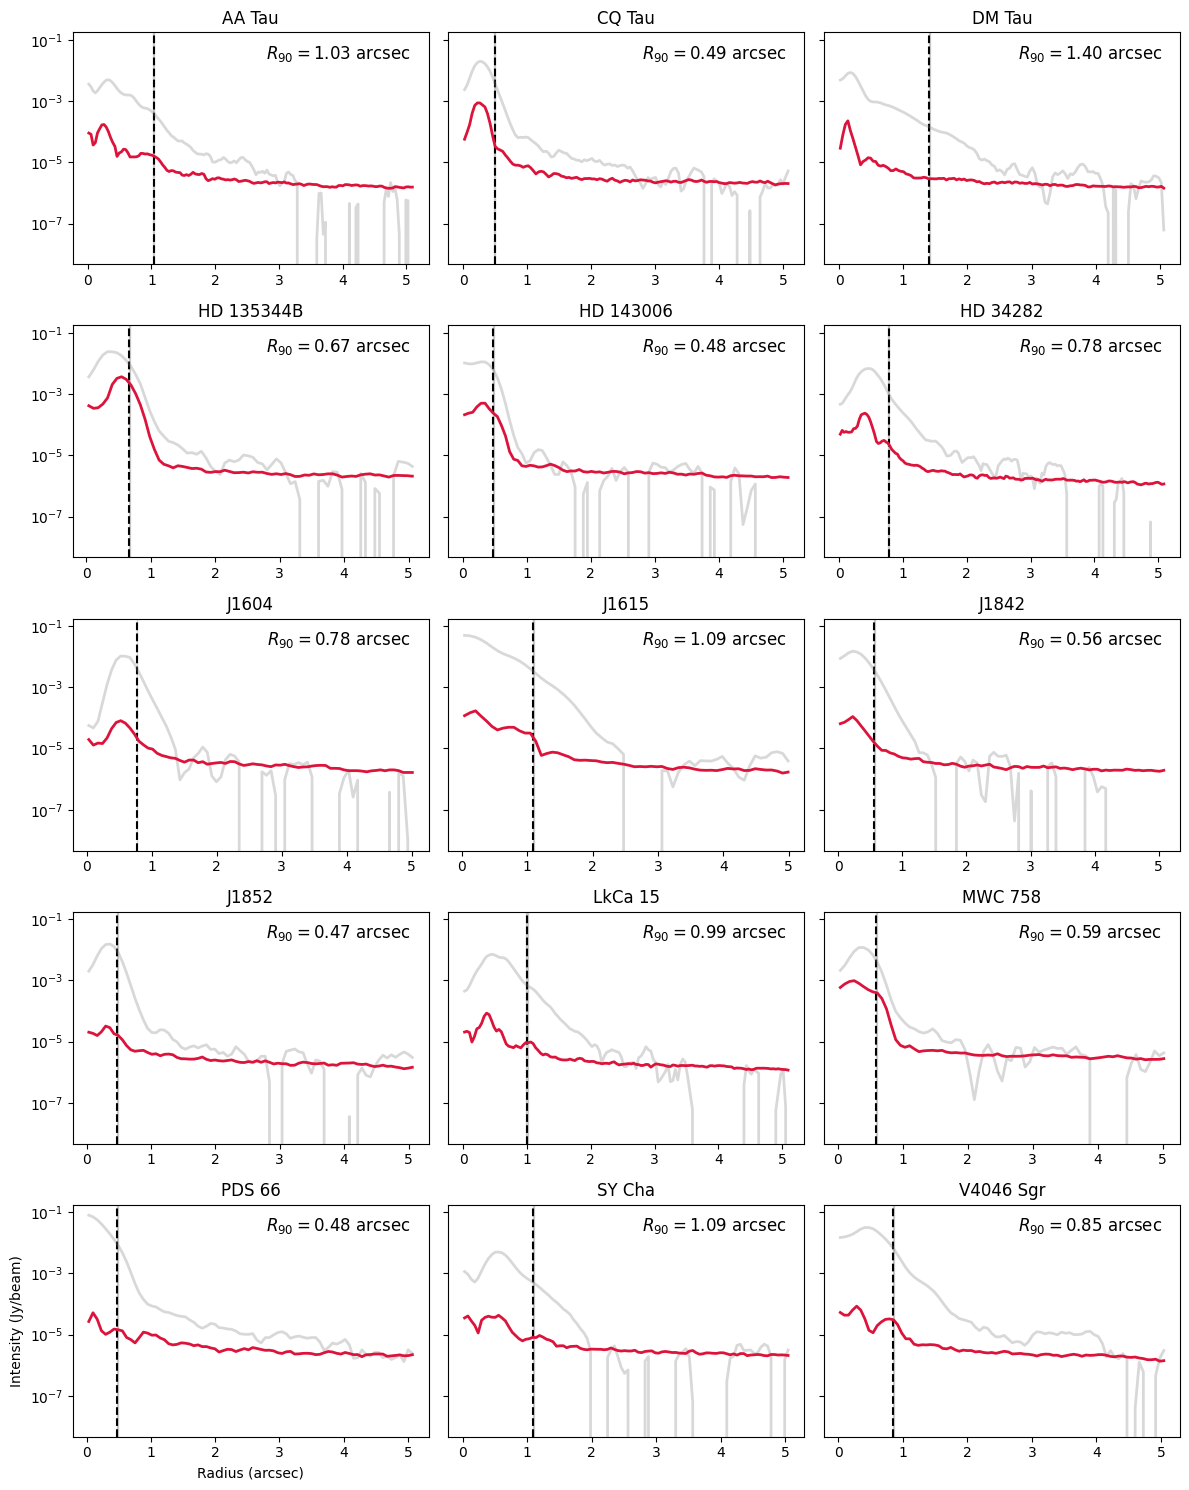

In [7]:

plot_profiles_new(None, robust_val="2.0", FOV=None, radius_unit="arcsec", use_full_fov=False, figsize=(12, 6), all_disks=all_disks)

### Chapter 2: Gaps

The origin of the gaps: how are they discovered. And the 

In [70]:
def plot_inner_profiles_with_gaps(all_disks, robust_val="1.0", radius_unit="au", figsize=(12, 15)):
    import matplotlib.pyplot as plt
    import numpy as np

    # Manuscript-style formatting
    plt.rcParams.update({
        "font.size": 8,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.titlesize": 9,
    })

    disk_names = list(all_disks.keys())
    n_disks = len(disk_names)
    ncols = 3
    nrows = 5
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = axes.flatten()

    for i, disk_name in enumerate(disk_names):
        disk_obj = all_disks[disk_name]
        ax = axes[i]

        # Load CLEAN radial profile
        rkey = disk_obj._rkey(robust_val)
        cube_clean = disk_obj.get_cube(rkey, cube_type="clean")
        x_cl, y_cl, dy_cl = cube_clean.radial_profile(
            inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
            assume_correlated=True, use_mad=True
        )

        # Mask beyond R90
        if hasattr(disk_obj, "disksize"):
            R90 = disk_obj.disksize["R90"] * (disk_obj.distance_pc if radius_unit == "au" else 1.0)
            mask = (x_cl * (disk_obj.distance_pc if radius_unit == "au" else 1.0)) <= R90
            x_cl = x_cl[mask]
            y_cl = y_cl[mask]

        # Convert radius
        if radius_unit == "au":
            x_cl = x_cl * disk_obj.distance_pc
            xlabel = "Radius (au)"
        else:
            xlabel = "Radius (arcsec)"

        # Plot CLEAN profile
        ax.plot(x_cl, y_cl, color="crimson", linewidth=1.6)

        # -------------------------
        # Gap / Ring annotation
        # -------------------------
        if hasattr(disk_obj, "ringgap") and disk_obj.ringgap is not None and disk_obj.ringgap.size > 0:
            rg = disk_obj.ringgap
            if rg.ndim == 1:
                rg = rg[np.newaxis, :]

            # Get axis limits
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()

            # Three tiers, close to the curve, clean
            tiers = [
                ymin + 0.70*(ymax - ymin),
                ymin + 0.60*(ymax - ymin),
                ymin + 0.50*(ymax - ymin),
            ]

            # Minimum horizontal spacing between labels
            min_dx = 0.05 * (xmax - xmin)   # 5% axis width

            # Sort by increasing radius
            rg_sorted = rg[np.argsort(rg[:, 0 if radius_unit=="au" else 1])]

            # Keep track of last label position in each tier
            last_x = [-1e9, -1e9, -1e9]

            for row in rg_sorted:

                # Radius + width
                if radius_unit == "au":
                    rad  = row[0]
                    width = None if np.isnan(row[3]) else row[3]
                else:
                    rad  = row[1]
                    width = None if np.isnan(row[4]) else row[4]

                flag = int(row[2])
                prefix = "B" if flag == 1 else "D"

                # Colors
                linecolor = "#4d794d" if flag == 1 else "#6b5b95"
                spancolor = linecolor + "44"

                # Span
                if width is not None and width > 0:
                    ax.axvspan(rad - width/2, rad + width/2, color=spancolor, lw=0)

                # Vertical line
                ax.axvline(rad, color=linecolor, linestyle=":", linewidth=1.1)

                # Pick the FIRST tier where the x separation is large enough
                for k in range(3):
                    if rad - last_x[k] >= min_dx:
                        tier_y = tiers[k]
                        last_x[k] = rad
                        break
                else:
                    # If all tiers are too close, force last tier
                    tier_y = tiers[-1]

                # Slight x offset
                xoff = 0.01 * (xmax - xmin)
                label_x = rad + xoff

                if label_x > xmax * 0.97:
                    ha = "right"
                    label_x = rad - xoff
                else:
                    ha = "left"

                # Clean rotated label
                ax.text(
                    label_x, tier_y,
                    f"{prefix}-{int(rad)}",
                    rotation=28,
                    ha=ha, va="center",
                    fontsize=9,
                    color=linecolor,
                    alpha=0.85
                )

        # Title
        ax.set_title(disk_obj.name.replace("_", " "))

        # Bottom-left labels only
        row = i // ncols
        col = i % ncols
        if row == nrows - 1 and col == 0:
            ax.set_xlabel(xlabel, fontsize=12)
            ax.set_ylabel("Intensity (Jy/beam)", fontsize=12)
        else:
            ax.set_xlabel("")
            ax.set_ylabel("")

        #ax.set_xlim(np.min(x_cl), np.max(x_cl))
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=4))
        ax.yaxis.set_minor_locator(plt.NullLocator())

    # Hide unused axes
    for ax in axes[n_disks:]:
        ax.axis("off")

    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()


	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal aver

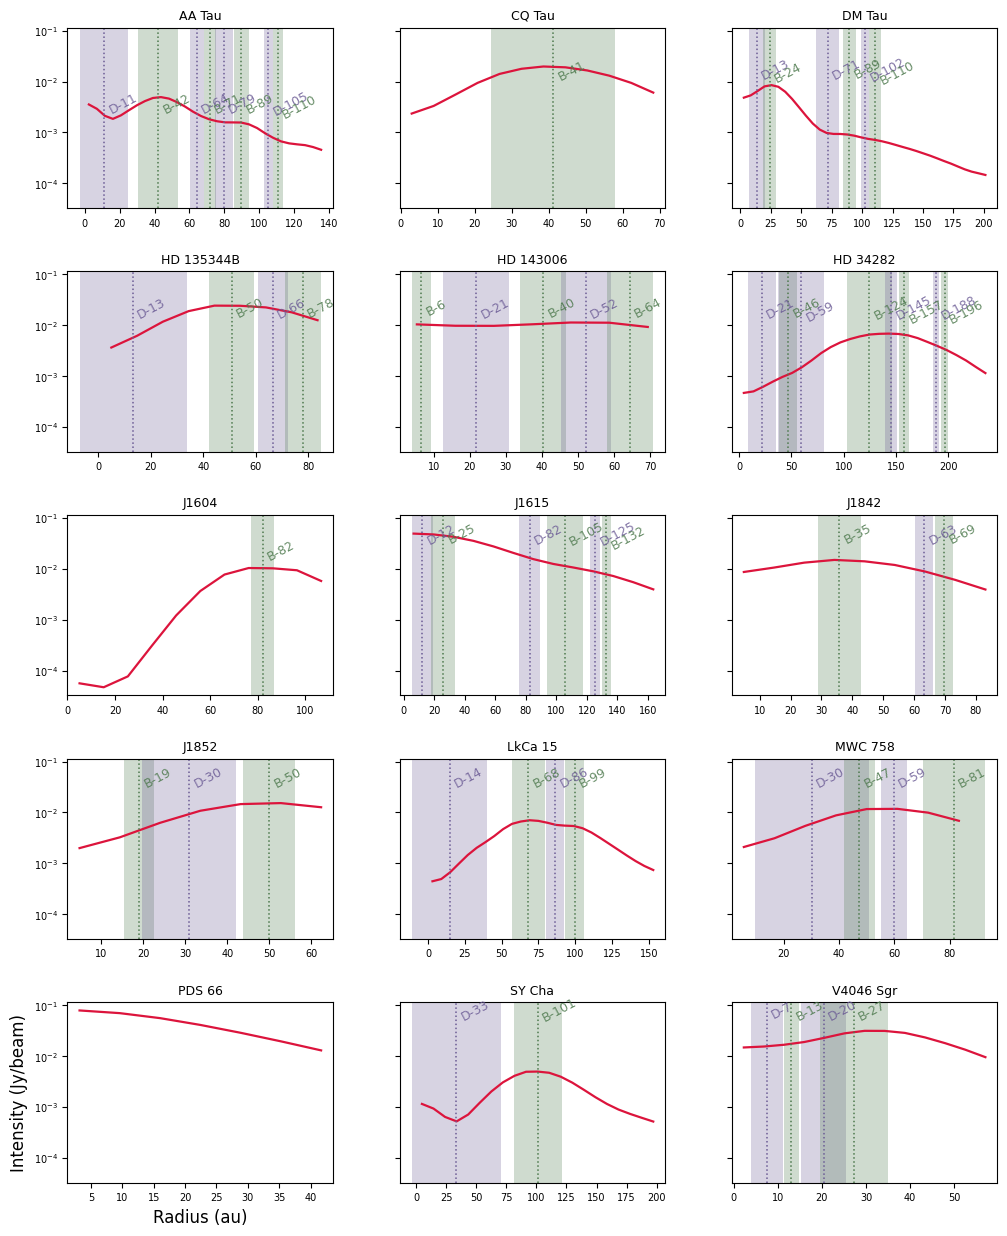

In [71]:
plot_inner_profiles_with_gaps(all_disks, robust_val="2.0", radius_unit="au", figsize=(12, 15))

### Chapter 3. Data...Model...Residual...

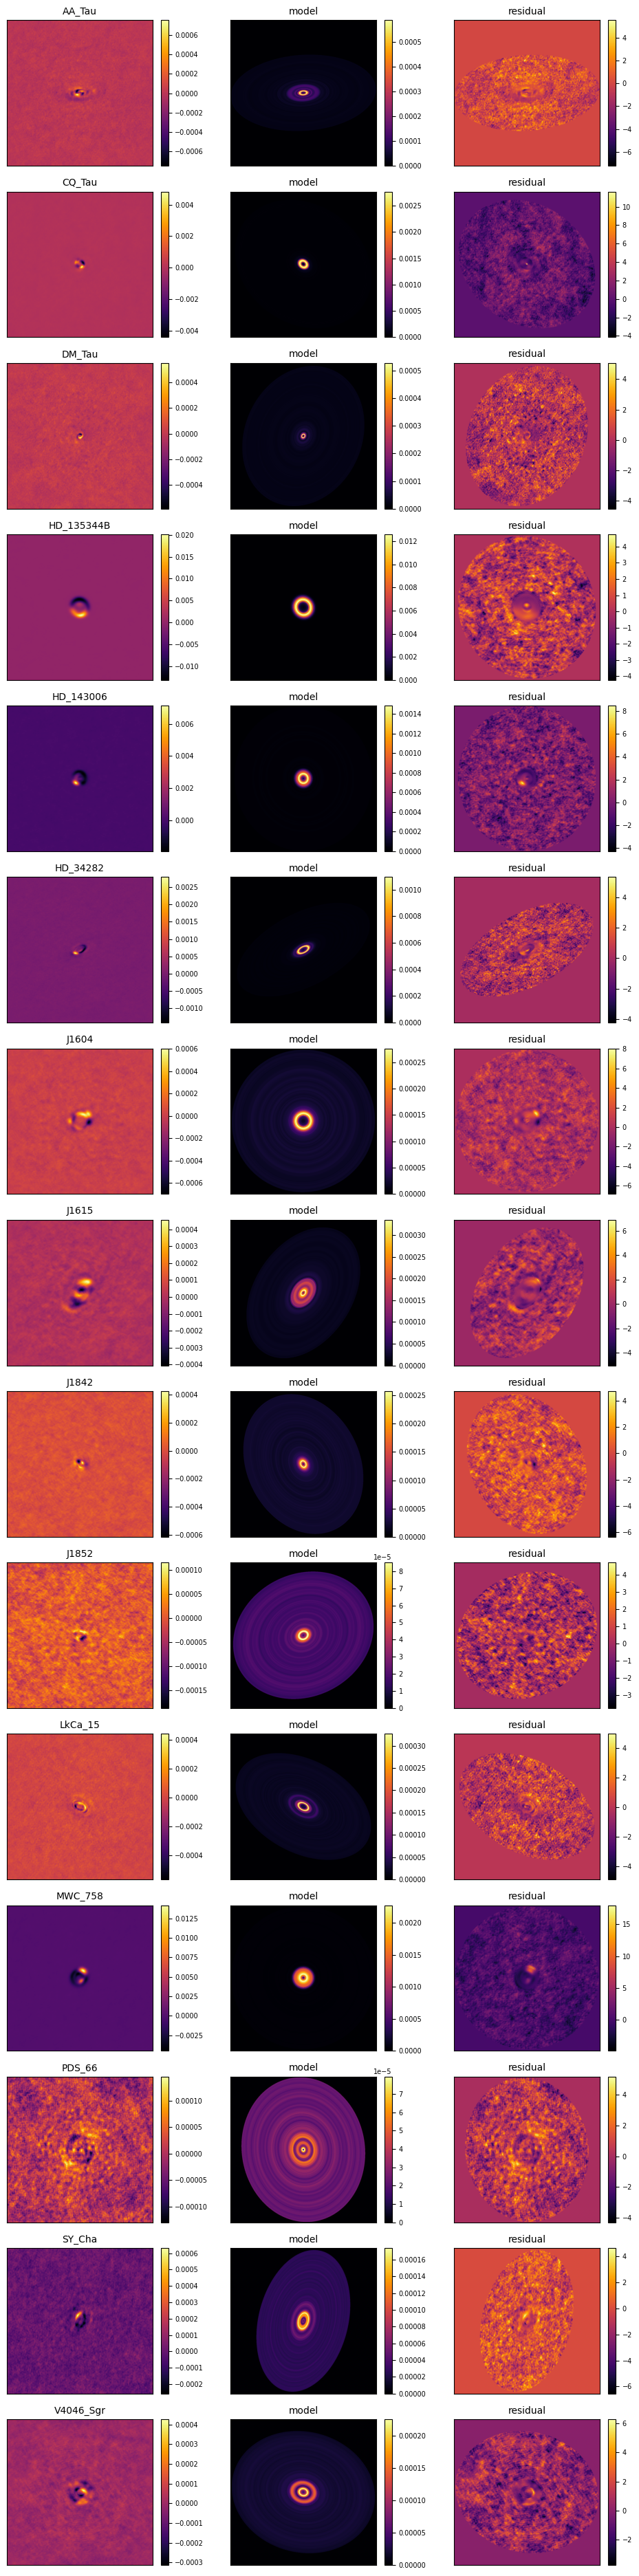

In [76]:
# Load everything as fits if possible   , easier to manipulate 
# data, SNR model , SNR plot
# a zzomed in plot for the sources 
# SNR_FITS in D:\CPD_MPIA\Median_SNR\SNR_FITS_Maps\AA_Tau_SNR_robust2.0.fits
# Noise Fits in D:\CPD_MPIA\Median_SNR\Disk_Residual_Profile_Median_SNR\AA_Tau\AA_Tau_sigma_mask_robust2.0.fits 
# original resiudal fits in exoALMA data    D:\exoALMA_disk_data\AA_Tau\images_frank_residuals_different_robust/AA_Tau_continuum_resid_robust2.0.image.fits

# Load fits

import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

disk_names = list(all_disks.keys())

data_dir = "D:/exoALMA_disk_data"
model_dir = "D:/CPD_MPIA/Median_SNR/Disk_Residual_Profile_Median_SNR"
snr_dir = "D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps"

def get_fits_path(disk, kind):
    if kind == "data":
        return os.path.join(data_dir, disk, "images_frank_residuals_different_robust", f"{disk}_continuum_resid_robust2.0.image.fits")
    elif kind == "model":
        return os.path.join(model_dir, disk, f"{disk}_sigma_mask_robust2.0.fits") # adjust filename as needed
    elif kind == "residual":
        return os.path.join(snr_dir, f"{disk}_SNR_robust2.0.fits")
    else:
        raise ValueError("Unknown kind")

n_disks = len(disk_names)
fig, axes = plt.subplots(n_disks, 3, figsize=(10, 2.5 * n_disks), squeeze=False)

for i, disk in enumerate(disk_names):
    for j, kind in enumerate(["data", "model", "residual"]):
        ax = axes[i, j]
        fits_path = get_fits_path(disk, kind)
        if os.path.exists(fits_path):
            img = fits.getdata(fits_path)
            # Squeeze to 2D if needed
            img = np.squeeze(img)
            if img.ndim > 2:
                img = img[-1, -1, :, :]
            im = ax.imshow(img, origin='lower', cmap='inferno')
            ax.set_title(f"{disk if j==0 else kind}", fontsize=10)
            # Add colorbar for each image
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.set_title(f"{disk} {kind} (missing)", fontsize=10)
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


### Chapter 4: Zoomed-In of The Sources